# 02 Derivatives, THDR, analytic signal, tilt

Derivatives sharpen anomalies and move their maxima toward source edges.
In the wavenumber domain (Blakely 12.17, 12.20):

    d/dx      H = (i kx)^n
    d/dy      H = (i ky)^n           y positive north
    d/dz      H = |k|^n              z positive down

Products built from the first derivatives:

    THDR = sqrt(dx^2 + dy^2)                  peaks over edges
    AS   = sqrt(dx^2 + dy^2 + dz^2)           Roest et al. 1992; peaks over edges,
                                              little dependence on field direction
    tilt = atan(dz / THDR)                    Miller and Singh 1994; +-90 deg,
                                              zero near the edge, same contrast for
                                              weak and strong anomalies

The vertical derivative convention is z down: the first vertical derivative
is positive over a positive peak. Units are field units per metre.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

## Check against an analytic field

`synthetic.point_mass` gives the gravity of a point mass and its exact
derivatives. The FFT derivatives should reproduce them away from the grid
edges. The tests in `tests/test_filters.py` do this on every run; here it is
as a profile.

RMS misfit / peak, d/dz: 0.0021135348596153774


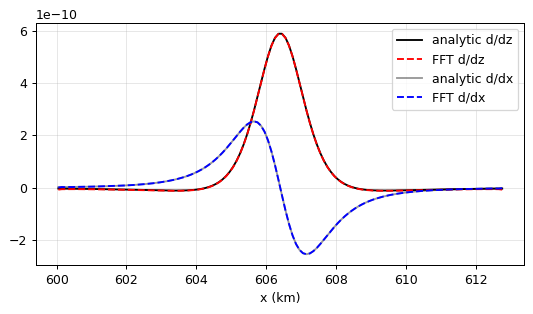

In [2]:
from potfield.synthetic import point_mass_grid
pm, exact = point_mass_grid(nx=128, ny=128, dx=100, z0=1500)
vd = filters.vertical_derivative(pm, 1)
gx, gy = filters.horizontal_derivatives(pm)
row = 64
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(pm.x / 1e3, exact["vd1"][row], "k", label="analytic d/dz")
ax.plot(pm.x / 1e3, vd.values[row], "r--", label="FFT d/dz")
ax.plot(pm.x / 1e3, exact["dx"][row], "k", alpha=0.4, label="analytic d/dx")
ax.plot(pm.x / 1e3, gx.values[row], "b--", label="FFT d/dx")
ax.set_xlabel("x (km)"); ax.legend(); ax.grid(alpha=0.3)
print("RMS misfit / peak, d/dz:", np.sqrt(np.mean((vd.values - exact["vd1"])**2)) / exact["vd1"].max())

## On the Frome TMI

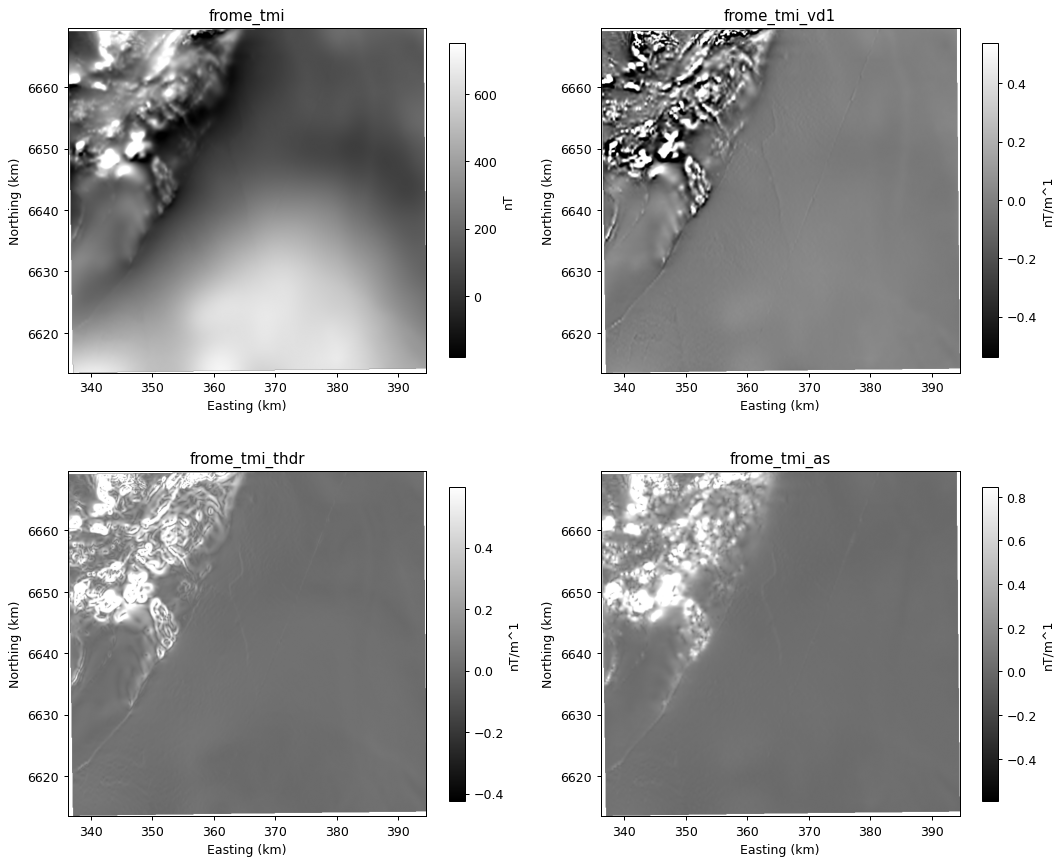

In [3]:
g = read_grid(f"{DATA}/frome_tmi.ers", bounds=(139.30, -30.60, 139.90, -30.10), epsg=28354, units="nT")
vd1 = filters.vertical_derivative(g, 1)
thdr = filters.total_horizontal_derivative(g)
asig = filters.analytic_signal(g)
tilt = filters.tilt_angle(g)
fig, axes = display.compare([g, vd1, thdr, asig], ncols=2, cmap="gray", clip=("std", 2.0))

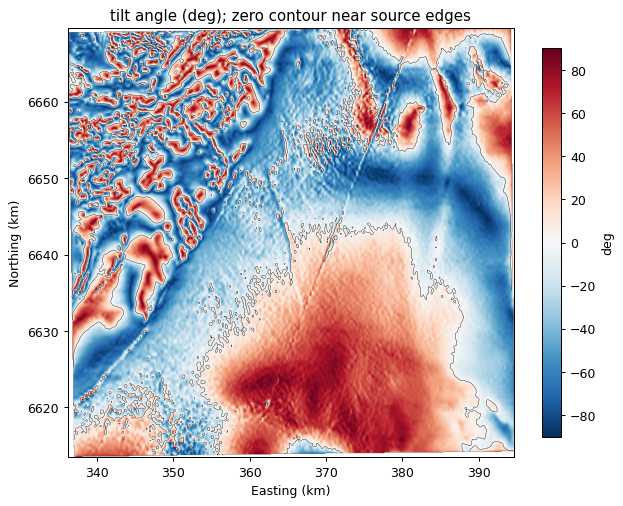

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
display.plot(tilt, ax=ax, cmap="RdBu_r", clip=(-90, 90), title="tilt angle (deg); zero contour near source edges")
ax.contour(tilt.x, tilt.y, tilt.values, levels=[0], colors="k", linewidths=0.3)

## Profile across the anomalies

`Grid.profile(start, end)` samples a grid along a straight line by bilinear
interpolation, one sample per cell. Start and end can be given in another
CRS with `epsg=`. Along one line the derivatives are easy to compare: the
vertical derivative narrows the peaks, THDR peaks over the edges where the
field changes fastest, and the tilt crosses zero close to those edges
regardless of anomaly amplitude.

682 samples over 58.1 km


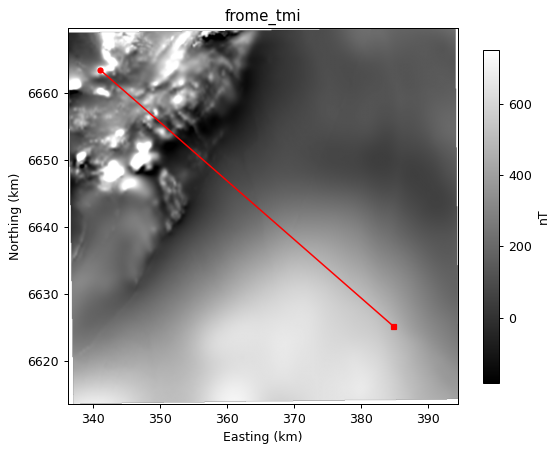

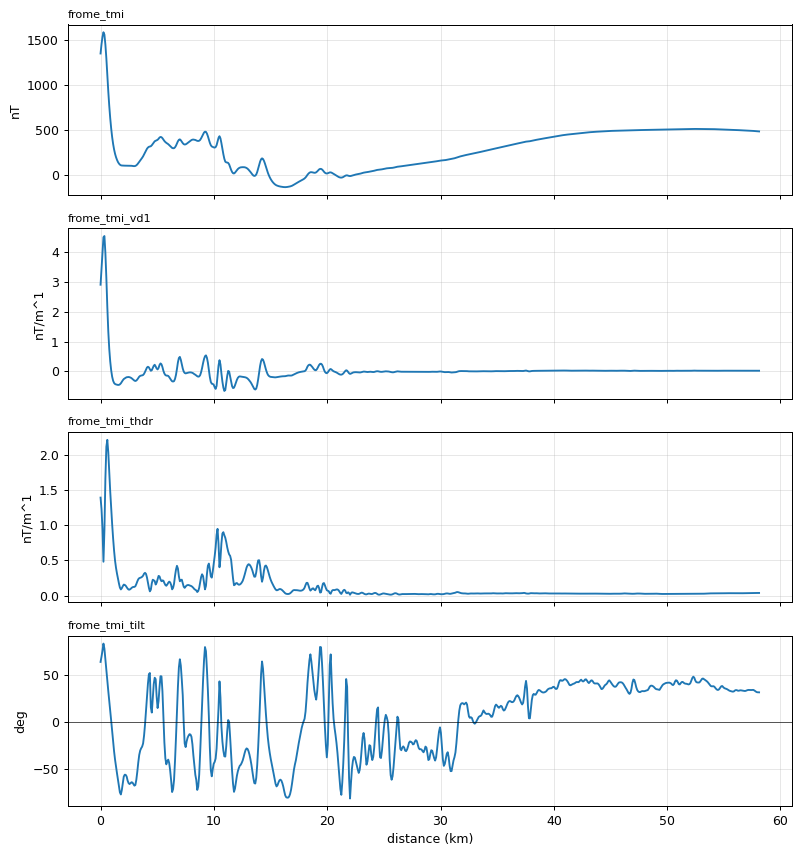

In [5]:
line = ((139.35, -30.15), (139.80, -30.50))          # lon, lat of start and end
profiles = [grid.profile(*line, epsg=4283) for grid in (g, vd1, thdr, tilt)]
print(f"{len(profiles[0])} samples over {profiles[0].length / 1e3:.1f} km")
fig, ax = plt.subplots(figsize=(7, 6))
display.plot(g, ax=ax, cmap="gray", clip=("std", 2.0))
display.plot_line(ax, profiles[0], color="r")
fig, axes = display.plot_profiles(profiles)
axes[3, 0].axhline(0, color="k", lw=0.5)

Fractional orders are allowed. Order 1.5 sits between the first and second
derivative and is sometimes preferred as a compromise between resolution
and noise.

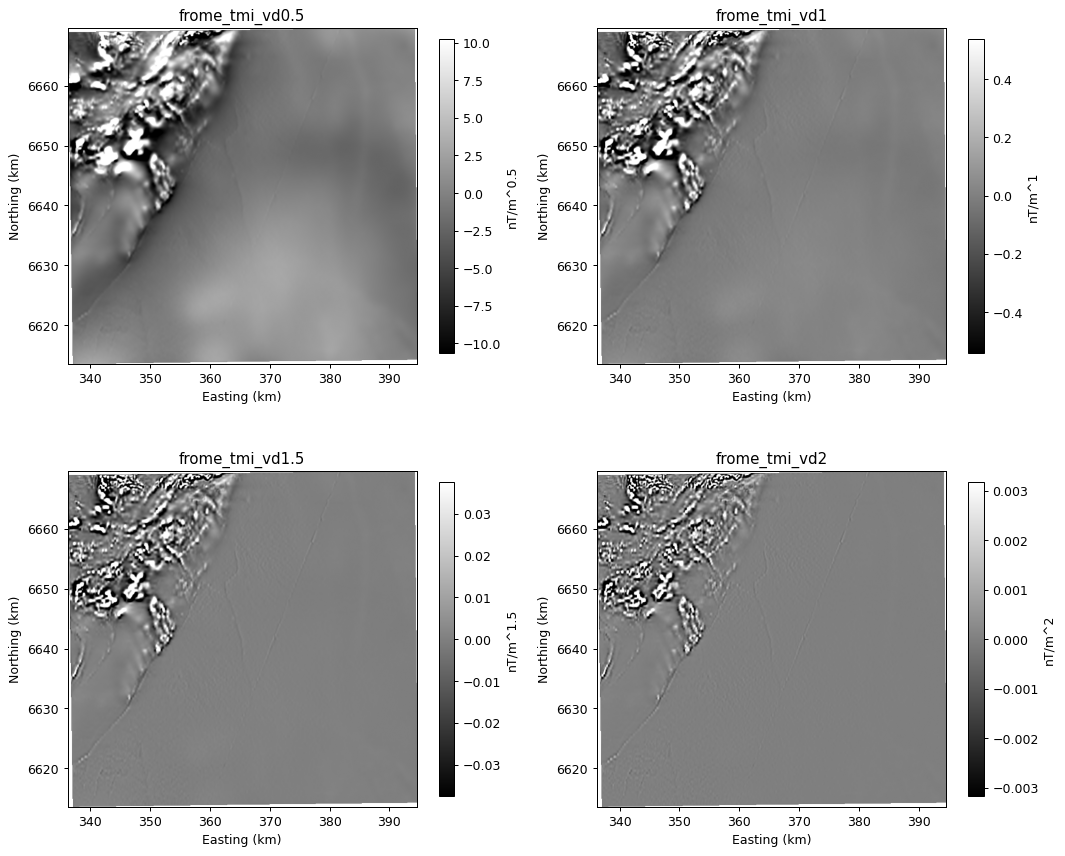

In [6]:
fig, axes = display.compare([filters.vertical_derivative(g, n) for n in (0.5, 1, 1.5, 2)], ncols=2, cmap="gray", clip=("std", 2.0))

In [7]:
import os
os.makedirs(OUT, exist_ok=True)
for grid in (vd1, thdr, asig, tilt):
    write_grid(grid, f"{OUT}/{grid.name}.grd")